# grahspj: Chimera Benchmark Notebook

This notebook provides a practical interface for running the Chimera stellar-mass benchmark from within Jupyter.

It covers three use cases:
- the built-in Chimera benchmark runner used by the CLI
- a low-`chimera_QSO_weight` COSMOS-like subset treated as effectively galaxy-only
- a high-`chimera_QSO_weight` subset that keeps the standard AGN-enabled Chimera configuration

Important caveat: the repository currently exposes only one formal benchmark API, `run_chimera_mass_benchmark()`. The COSMOS-like and AGN-heavy slices below are notebook-level analyses built from the same Chimera rows.


## Prerequisites

This notebook assumes:
- you are running from the `notebooks/` directory of this repository
- `grahspj` and its dependencies are installed
- the Chimera benchmark FITS files are present under `data/chimeras-2023-10-11/`
- a valid DSPS SSP file is available

By default the notebook looks for `../jaxqsofit/tempdata.h5` as a sibling checkout.


In [8]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np

project_root = Path.cwd().resolve().parent
src_root = project_root / "src"
if str(src_root) not in sys.path:
    sys.path.insert(0, str(src_root))

from grahspj.benchmark import (
    build_chimera_fit_config,
    compute_weighted_metrics,
    load_chimera_benchmark_dataset,
    run_chimera_mass_benchmark,
    select_chimera_subset,
)
from grahspj.core import GRAHSPJ
from grahspj.mplstyle import style_path

plt.style.use(style_path())


In [9]:
dsps_ssp_fn = project_root.parent / "jaxqsofit" / "tempdata.h5"
assert dsps_ssp_fn.is_file(), f"DSPS SSP file not found: {dsps_ssp_fn}"

dataset = load_chimera_benchmark_dataset(project_root)
subset = select_chimera_subset(dataset, project_root)

qso_weights = np.array([row["chimera_QSO_weight"] for row in subset], dtype=float)
redshifts = np.array([row["redshift"] for row in subset], dtype=float)

print("Deterministic subset size:", len(subset))
print("QSO-weight percentiles:", np.percentile(qso_weights, [0, 25, 50, 75, 90, 95, 100]))
print("Redshift percentiles:", np.percentile(redshifts, [0, 25, 50, 75, 90, 95, 100]))


[benchmark] Loading Chimera photometry from /Users/colinburke/research/grahspj/data/chimeras-2023-10-11/chimeras-grahsp.fits
[benchmark] Loading Chimera truth table from /Users/colinburke/research/grahspj/data/chimeras-2023-10-11/chimeras-fullinfo.fits
[benchmark] Joined 18168 Chimera rows
[benchmark] Loading deterministic subset from /Users/colinburke/research/grahspj/data/chimeras-2023-10-11/benchmark_subset_ids.txt
[benchmark] Selected 270 benchmark rows
Deterministic subset size: 270
QSO-weight percentiles: [1.e-04 1.e-03 1.e-02 1.e-01 1.e+00 1.e+00 1.e+00]
Redshift percentiles: [0.0785     0.52737501 0.9016     1.64932498 2.79908993 3.10383004
 3.67000008]


In [10]:
cosmos_like_rows = [row for row in subset if float(row["chimera_QSO_weight"]) <= 1.0e-3]
agn_like_rows = [row for row in subset if float(row["chimera_QSO_weight"]) >= 1.0e-1]

print("COSMOS-like low-QSO subset:", len(cosmos_like_rows))
print("AGN-contaminated subset:", len(agn_like_rows))

print("Example COSMOS-like row:", cosmos_like_rows[0]["id"], cosmos_like_rows[0]["ID_COSMOS"], cosmos_like_rows[0]["chimera_QSO_weight"])
print("Example AGN-like row:", agn_like_rows[0]["id"], agn_like_rows[0]["ID_COSMOS"], agn_like_rows[0]["chimera_QSO_weight"])


COSMOS-like low-QSO subset: 90
AGN-contaminated subset: 90
Example COSMOS-like row: 135639.12+051950.9_712542_0.001 712542 0.001
Example AGN-like row: 174112.44+535632.5_496869_0.3 496869 0.3


## Built-In Chimera Benchmark

This is the same path used by `grahspj-benchmark` and `python -m grahspj.benchmark`.

It always uses the standard Chimera fit configuration, including the AGN component model seeded from each row photometry. For notebook iteration, start with a small `limit` and `num_workers=1`.


## Custom Subset Benchmarks

The helper below runs the same MAP fitting path row by row and computes the same weighted stellar-mass metrics.

For the COSMOS-like subset, the notebook turns AGN fitting off explicitly:

- `cfg.agn.fit_agn = False`

This removes the AGN parameter block entirely and makes the slice genuinely host-only.

When AGN fitting is left on, the AGN normalization is inferred directly from the photometry rather than being tied to the host 5100 A continuum.


In [11]:
def run_subset_mass_benchmark(
    rows,
    label,
    *,
    limit=10,
    galaxy_only=False,
    map_steps=600,
    learning_rate=5e-3,
    extra_priors=None,
):
    selected = list(rows[:limit] if limit is not None else rows)
    out_rows = []

    for idx, row in enumerate(selected, start=1):
        print(f"[{label}] Starting {row['id']} with QSO weight {row['chimera_QSO_weight']} and redshift {row['redshift']}")
        cfg = build_chimera_fit_config(row, dsps_ssp_fn=str(dsps_ssp_fn))
        cfg.inference.map_steps = int(map_steps)
        cfg.inference.learning_rate = float(learning_rate)
        if extra_priors:
            cfg.prior_config.update(extra_priors)

        # Broad stellar mass prior
        cfg.prior_config["log_stellar_mass"] = {
            "dist": "uniform",
            "low": 6.0,
            "high": 12.0,
        }

        if galaxy_only:
            cfg.agn.fit_agn = False

        print(
            f"[{label}] Config for {row['id']}: map_steps={cfg.inference.map_steps}, learning_rate={cfg.inference.learning_rate}, fit_agn={cfg.agn.fit_agn}"
        )

        try:
            fitter = GRAHSPJ(cfg)

            print(f"[{label}] Running fit for {row['id']}...")
            
            fit_result = fitter.fit(
                fit_method="optax+nuts",
                prior_config=cfg.prior_config,
                dsps_ssp_fn=cfg.galaxy.dsps_ssp_fn,
                optax_steps=cfg.inference.map_steps,
                optax_lr=cfg.inference.learning_rate,
                nuts_warmup=50,
                nuts_samples=50,
                plot_fig=False,
                save_fig=False,
                save_result=False,
                progress_bar=False,
            )
            logm_samples = np.asarray(fitter.samples["log_stellar_mass"], dtype=float).reshape(-1)
            logm16, logm_fit, logm84 = np.percentile(logm_samples, [16.0, 50.0, 84.0])
            logm_err_lo = float(max(0.0, logm_fit - logm16))
            logm_err_hi = float(max(0.0, logm84 - logm_fit))
        except Exception as exc:
            print(f"[{label}] failed on {row['id']}: {type(exc).__name__}: {exc}")
            logm_fit = np.nan
            logm_err_lo = np.nan
            logm_err_hi = np.nan

        out_rows.append(
            {
                "id": row["id"],
                "ID_COSMOS": row["ID_COSMOS"],
                "redshift": float(row["redshift"]),
                "chimera_QSO_weight": float(row["chimera_QSO_weight"]),
                "resample_weight": float(row["resample_weight"]),
                "log_stellar_mass_truth": float(row["log_stellar_mass_truth"]),
                "log_stellar_mass_fit": float(logm_fit),
                "log_stellar_mass_fit_err_lo": float(logm_err_lo),
                "log_stellar_mass_fit_err_hi": float(logm_err_hi),
            }
        )
        print(f"[{label}] {idx:03d}/{len(selected)} {row['id']} -> {logm_fit:.3f}")

    finite_rows = [row for row in out_rows if np.isfinite(row["log_stellar_mass_fit"])]
    if finite_rows:
        metrics = compute_weighted_metrics(
            np.array([row["log_stellar_mass_fit"] for row in finite_rows], dtype=float),
            np.array([row["log_stellar_mass_truth"] for row in finite_rows], dtype=float),
            np.array([row["resample_weight"] for row in finite_rows], dtype=float),
        )
    else:
        metrics = {
            "weighted_bias": np.nan,
            "weighted_mae": np.nan,
            "weighted_rmse": np.nan,
            "weighted_medae": np.nan,
            "weighted_pearson": np.nan,
        }

    metrics["n_rows"] = len(out_rows)
    metrics["n_finite_rows"] = len(finite_rows)
    metrics["finite_fit_fraction"] = len(finite_rows) / max(1, len(out_rows))

    return {"label": label, "rows": out_rows, "metrics": metrics}


def compare_subset_metrics(*results):
    keys = ["weighted_bias", "weighted_mae", "weighted_rmse", "weighted_medae", "weighted_pearson", "finite_fit_fraction"]
    rows = []
    for result in results:
        row = {"label": result["label"]}
        row.update({key: result["metrics"].get(key, np.nan) for key in keys})
        rows.append(row)
    return rows

    
def plot_subset_result(result):
    rows = result["rows"]
    fit = np.array([row["log_stellar_mass_fit"] for row in rows], dtype=float)
    truth = np.array([row["log_stellar_mass_truth"] for row in rows], dtype=float)
    fit_err_lo = np.array([row.get("log_stellar_mass_fit_err_lo", np.nan) for row in rows], dtype=float)
    fit_err_hi = np.array([row.get("log_stellar_mass_fit_err_hi", np.nan) for row in rows], dtype=float)
    qso = np.array([row["chimera_QSO_weight"] for row in rows], dtype=float)
    finite = np.isfinite(fit) & np.isfinite(truth) & np.isfinite(qso) & (qso > 0)
    finite_err = finite & np.isfinite(fit_err_lo) & np.isfinite(fit_err_hi)

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    axes[0].errorbar(
        truth[finite_err],
        fit[finite_err],
        yerr=np.vstack([fit_err_lo[finite_err], fit_err_hi[finite_err]]),
        fmt="none",
        ecolor="0.7",
        elinewidth=0.8,
        capsize=2,
        zorder=1,
    )
    log_qso = np.log10(qso[finite])
    sc0 = axes[0].scatter(truth[finite], fit[finite], c=log_qso, s=26, cmap="viridis", zorder=2)

    if np.any(finite):
        lo = float(min(np.min(truth[finite]), np.min(fit[finite])))
        hi = float(max(np.max(truth[finite]), np.max(fit[finite])))
        axes[0].plot([lo, hi], [lo, hi], color="black", ls="--", lw=1.0)

    axes[0].set_xlabel("Truth log stellar mass")
    axes[0].set_ylabel("Fit log stellar mass")
    axes[0].set_title(result["label"])

    resid = fit - truth
    axes[1].errorbar(
        qso[finite_err],
        resid[finite_err],
        yerr=np.vstack([fit_err_lo[finite_err], fit_err_hi[finite_err]]),
        fmt="o",
        ms=4,
        color="tab:blue",
        ecolor="0.7",
        elinewidth=0.8,
        capsize=2,
    )
    axes[1].axhline(0.0, color="black", ls="--", lw=1.0)
    axes[1].set_xscale("log")
    axes[1].set_xlabel("chimera_QSO_weight")
    axes[1].set_ylabel("Fit - Truth")
    axes[1].set_title("Residual vs QSO weight")

    fig.colorbar(sc0, ax=axes[0], label="log10(chimera_QSO_weight)")

    fig.tight_layout()
    return fig


In [12]:
mass_metallicity_prior = {
    "enabled": True,
    "pivot_mass": 10.0,
    "pivot_logzsol": -0.2,
    "slope": 0.3,
    "scale": 0.3,
    "redshift_ref": 0.0,
    "redshift_slope": -0.1,
    "min": -1.5,
    "max": 0.3,
}

cosmos_like_benchmark = run_subset_mass_benchmark(
    cosmos_like_rows,
    "COSMOS-like low-QSO subset (baseline)",
    limit=20,
    galaxy_only=False,
)

cosmos_like_benchmark_mzr = run_subset_mass_benchmark(
    cosmos_like_rows,
    "COSMOS-like low-QSO subset (mass-metallicity prior)",
    limit=20,
    galaxy_only=False,
    extra_priors={"mass_metallicity_relation": mass_metallicity_prior},
)

compare_subset_metrics(cosmos_like_benchmark, cosmos_like_benchmark_mzr)


[COSMOS-like low-QSO subset (baseline)] Starting 135639.12+051950.9_712542_0.001 with QSO weight 0.001 and redshift 1.3899999856948853
[COSMOS-like low-QSO subset (baseline)] Config for 135639.12+051950.9_712542_0.001: map_steps=600, learning_rate=0.005, fit_agn=True
[COSMOS-like low-QSO subset (baseline)] Running fit for 135639.12+051950.9_712542_0.001...
[COSMOS-like low-QSO subset (baseline)] 001/20 135639.12+051950.9_712542_0.001 -> 10.522
[COSMOS-like low-QSO subset (baseline)] Starting 173506.26+543008.3_698114_0.0001 with QSO weight 0.0001 and redshift 0.6784999966621399
[COSMOS-like low-QSO subset (baseline)] Config for 173506.26+543008.3_698114_0.0001: map_steps=600, learning_rate=0.005, fit_agn=True
[COSMOS-like low-QSO subset (baseline)] Running fit for 173506.26+543008.3_698114_0.0001...
[COSMOS-like low-QSO subset (baseline)] 002/20 173506.26+543008.3_698114_0.0001 -> 9.007
[COSMOS-like low-QSO subset (baseline)] Starting 140709.34+012420.0_701398_0.0003 with QSO weight 0.

[{'label': 'COSMOS-like low-QSO subset (baseline)',
  'weighted_bias': 0.16973334179499502,
  'weighted_mae': 0.33001699460139183,
  'weighted_rmse': 0.4527238512209008,
  'weighted_medae': 0.27156839547720835,
  'weighted_pearson': 0.9364317820753519,
  'finite_fit_fraction': 1.0},
 {'label': 'COSMOS-like low-QSO subset (mass-metallicity prior)',
  'weighted_bias': 0.27226856098110197,
  'weighted_mae': 0.2841770644765045,
  'weighted_rmse': 0.40570238150776594,
  'weighted_medae': 0.19560504229598277,
  'weighted_pearson': 0.9711879313877126,
  'finite_fit_fraction': 1.0}]

In [13]:
agn_like_benchmark = run_subset_mass_benchmark(
    agn_like_rows,
    "AGN-contaminated subset (baseline)",
    limit=20,
    galaxy_only=False,
)

agn_like_benchmark_mzr = run_subset_mass_benchmark(
    agn_like_rows,
    "AGN-contaminated subset (mass-metallicity prior)",
    limit=20,
    galaxy_only=False,
    extra_priors={"mass_metallicity_relation": mass_metallicity_prior},
)

compare_subset_metrics(agn_like_benchmark, agn_like_benchmark_mzr)


[AGN-contaminated subset (mass-metallicity prior)] Starting 174112.44+535632.5_496869_0.3 with QSO weight 0.3 and redshift 0.8414000272750854
[AGN-contaminated subset (mass-metallicity prior)] Config for 174112.44+535632.5_496869_0.3: map_steps=600, learning_rate=0.005, fit_agn=True
[AGN-contaminated subset (mass-metallicity prior)] Running fit for 174112.44+535632.5_496869_0.3...
[AGN-contaminated subset (mass-metallicity prior)] 001/20 174112.44+535632.5_496869_0.3 -> 10.304
[AGN-contaminated subset (mass-metallicity prior)] Starting 093419.45+592904.4_707486_0.3 with QSO weight 0.3 and redshift 1.6500999927520752
[AGN-contaminated subset (mass-metallicity prior)] Config for 093419.45+592904.4_707486_0.3: map_steps=600, learning_rate=0.005, fit_agn=True
[AGN-contaminated subset (mass-metallicity prior)] Running fit for 093419.45+592904.4_707486_0.3...
[AGN-contaminated subset (mass-metallicity prior)] 002/20 093419.45+592904.4_707486_0.3 -> 10.634
[AGN-contaminated subset (mass-metal

NameError: name 'agn_like_benchmark' is not defined

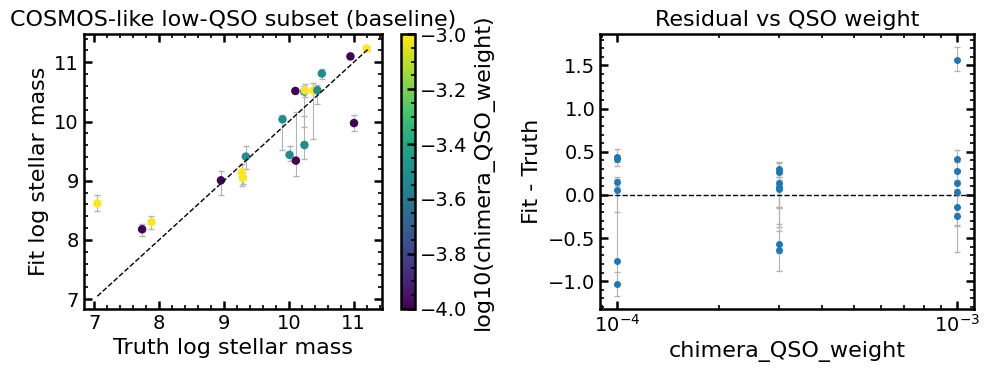

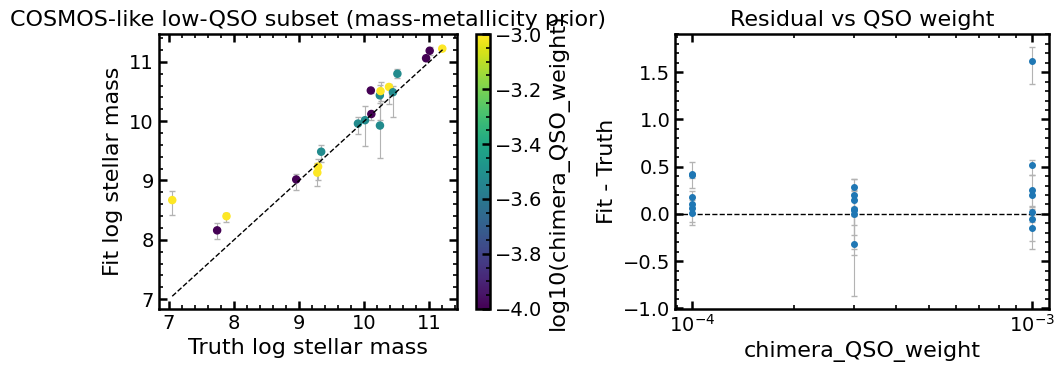

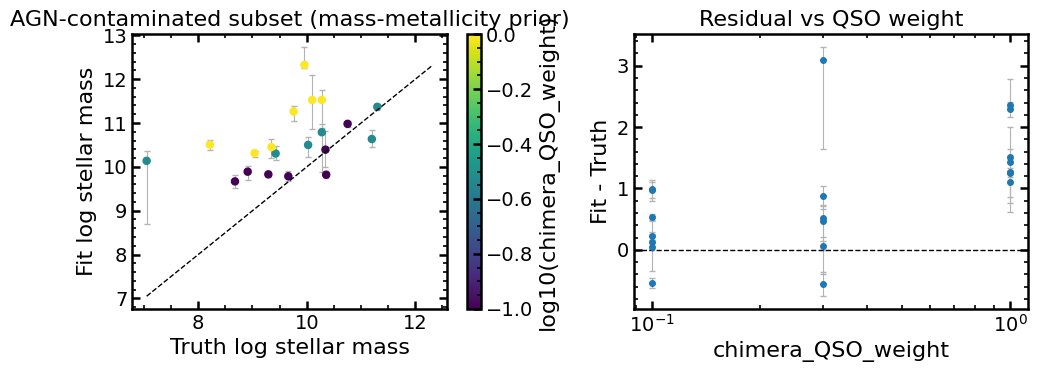

In [14]:
plot_subset_result(cosmos_like_benchmark);
plot_subset_result(cosmos_like_benchmark_mzr);
plot_subset_result(agn_like_benchmark);
plot_subset_result(agn_like_benchmark_mzr);
plt.show()


## Notes

- The official benchmark is the only built-in regression path in the package today.
- The COSMOS-like and AGN-like slices in this notebook are analysis conveniences, not separate packaged datasets.
- The COSMOS-like slice is run with `cfg.agn.fit_agn = False`, so the AGN block is removed entirely.
- The AGN normalization is inferred directly from the photometry when AGN fitting is enabled.
- Increase `limit`, `map_steps`, or switch to the CLI benchmark once you are satisfied the notebook path is behaving as expected.
